----
# **<span style="color:darkmagenta">PROYECTO EDA - BANK MARKETING</span>**
----

---
---
## <span style="color:gray">**1. Importación de librerías**</span> 📂

In [2]:
# Tratamiento de datos 
import numpy as np
import pandas as pd 

# Visualización de datos
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Configuración de ruta
import sys
sys.path.append('../')

# Importación de funciones personalizadas
from src.soporte3_EDA import *
from src.soporte1_preliminar import *
from src.soporte2_limpieza import eliminar_columns

---
---
## <span style="color:gray">**2. Carga de datos**</span> 📥

In [3]:
# Utilizamos los datos que hemos guardado tras la limpieza
booking_eu = pd.read_csv("../data/output/booking_eu.csv")
reviews_limpio = pd.read_csv("../data/output/reviews_limpio.csv")

In [4]:
# Configuración para mostrar todas las columnas
pd.set_option('display.max_columns', None) 

----
# <span style="color:DarkSlateBlue">**Desarrollo del proyecto - 3**</span> 
----


---
---
## <span style="color:gray">**Integración de datasets**</span> 🔗

In [5]:
booking_agg = booking_eu.groupby(
    ['arrival_year_month', 'country']
).agg({
    # numéricas → medias
    'lead_time': 'mean',
    'stays_in_weekend_nights': 'mean',
    'stays_in_week_nights': 'mean',
    'adults': 'mean',
    'children': 'mean',
    'babies': 'mean',
    'previous_cancellations': 'mean',
    'previous_bookings_not_canceled': 'mean',
    'booking_changes': 'mean',
    'adr': 'mean',
    'total_nights': 'mean',
    'total_guests': 'mean',

    # categóricas → moda
    'hotel': lambda x: x.mode()[0],
    'meal': lambda x: x.mode()[0],
    'market_segment': lambda x: x.mode()[0],
    'is_repeated_guest': lambda x: x.mode()[0],
    'reserved_room_type': lambda x: x.mode()[0],
    'assigned_room_type': lambda x: x.mode()[0],
    'deposit_type': lambda x: x.mode()[0],
    'customer_type': lambda x: x.mode()[0],
    'reservation_status': lambda x: x.mode()[0],

}).reset_index()

In [6]:
reviews_agg = reviews_limpio.groupby(
    ['review_year_month', 'country']
).agg({
    # numéricas → medias
    'average_score': 'mean',
    'reviewer_score': 'mean',
    'total_number_of_reviews': 'mean',
    'total_number_of_reviews_reviewer_has_given': 'mean',
    'nights': 'mean',

    # categóricas → moda
    'hotel_name': lambda x: x.mode()[0],
    'reviewer_nationality': lambda x: x.mode()[0],
    'positive_tag': lambda x: x.mode()[0],
    'negative_tag': lambda x: x.mode()[0],
    'trip_type': lambda x: x.mode()[0],
    'group_type': lambda x: x.mode()[0]
}).reset_index()

In [7]:
df_final = booking_agg.merge(
    reviews_agg,
    left_on=['arrival_year_month', 'country'],
    right_on=['review_year_month', 'country'],
    how='inner'
).drop(columns=['review_year_month'])

In [8]:
eda_preliminar(df_final)



👀 Visualización de las primeras y últimas filas



,arrival_year_month,country,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,previous_cancellations,previous_bookings_not_canceled,booking_changes,adr,total_nights,total_guests,hotel,meal,market_segment,is_repeated_guest,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,average_score,reviewer_score,total_number_of_reviews,total_number_of_reviews_reviewer_has_given,nights,hotel_name,reviewer_nationality,positive_tag,negative_tag,trip_type,group_type
0,2015-08,austria,51.166667,1.166667,2.500000,2.000000,0.000000,0.000000,0.0,0.0,0.000000,93.166667,3.666667,2.000000,city_hotel,bb,online_ta,no,a,a,no_deposit,transient,check_out,8.594389,8.438119,2354.198020,11.203520,2.790979,austria_trend_hotel_savoyen_vienna,united_kingdom,staff,other,leisure_trip,couple
1,2015-08,france,39.738889,1.005556,2.622222,1.911111,0.166667,0.011111,0.0,0.0,0.227778,108.831278,3.627778,2.088889,city_hotel,bb,online_ta,no,a,a,no_deposit,transient,check_out,8.361995,8.331368,1453.671159,7.739892,2.913747,mercure_paris_terminus_nord,united_kingdom,staff,other,leisure_trip,couple
2,2015-08,italy,92.353535,1.762626,1.353535,1.939394,0.025253,0.000000,0.0,0.0,0.252525,93.021061,3.116162,1.964646,city_hotel,hb,offline_ta_to,no,a,a,no_deposit,transient_party,check_out,8.438591,8.317195,3254.060116,10.723982,2.306399,hotel_da_vinci,united_kingdom,staff,other,leisure_trip,couple


,arrival_year_month,country,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,previous_cancellations,previous_bookings_not_canceled,booking_changes,adr,total_nights,total_guests,hotel,meal,market_segment,is_repeated_guest,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,average_score,reviewer_score,total_number_of_reviews,total_number_of_reviews_reviewer_has_given,nights,hotel_name,reviewer_nationality,positive_tag,negative_tag,trip_type,group_type
122,2017-08,italy,152.175610,1.131707,3.058537,2.053659,0.175610,0.004878,0.000000,0.019512,0.351220,156.912049,4.190244,2.234146,city_hotel,bb,online_ta,no,a,a,no_deposit,transient,check_out,8.348131,8.306542,3476.593458,8.514019,2.186916,hotel_da_vinci,united_kingdom,staff,other,leisure_trip,couple
123,2017-08,netherlands,138.202128,0.829787,2.382979,2.063830,0.425532,0.000000,0.000000,0.010638,0.223404,152.198830,3.212766,2.489362,city_hotel,bb,online_ta,no,a,a,no_deposit,transient,check_out,8.393452,8.375000,3594.175595,6.705357,2.693452,the_student_hotel_amsterdam_city,united_kingdom,staff,other,leisure_trip,couple
124,2017-08,spain,110.542342,1.048649,3.009009,2.073874,0.351351,0.014414,0.001802,0.003604,0.304505,201.510270,4.057658,2.439640,resort_hotel,bb,online_ta,no,a,a,no_deposit,transient,check_out,8.494444,8.575617,2220.984568,4.765432,3.246914,ayre_hotel_gran_v_a,united_kingdom,staff,other,leisure_trip,couple




------------------------------------------------------------------------


🎲 Visualización de filas aleatorias



,arrival_year_month,country,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,previous_cancellations,previous_bookings_not_canceled,booking_changes,adr,total_nights,total_guests,hotel,meal,market_segment,is_repeated_guest,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,average_score,reviewer_score,total_number_of_reviews,total_number_of_reviews_reviewer_has_given,nights,hotel_name,reviewer_nationality,positive_tag,negative_tag,trip_type,group_type
71,2016-10,france,113.408000,0.864000,2.179200,1.865600,0.121600,0.008000,0.0016,0.008000,0.180800,108.344832,3.043200,1.995200,city_hotel,bb,online_ta,no,a,a,no_deposit,transient,check_out,8.406305,8.328262,1206.748534,7.353739,2.628299,mercure_paris_terminus_nord,united_kingdom,staff,other,leisure_trip,couple
77,2016-11,italy,64.860606,0.763636,2.278788,1.866667,0.084848,0.000000,0.0000,0.000000,0.272727,95.400242,3.042424,1.951515,city_hotel,bb,online_ta,no,a,a,no_deposit,transient,check_out,8.434002,8.373216,3327.622294,10.093825,2.239775,hotel_da_vinci,united_kingdom,staff,other,leisure_trip,couple
44,2016-04,spain,37.037313,0.514925,1.921642,1.906716,0.130597,0.007463,0.0000,0.022388,0.216418,100.303321,2.436567,2.044776,resort_hotel,bb,online_ta,no,a,a,no_deposit,transient,check_out,8.506139,8.508282,2361.560775,7.195303,3.105480,barcelona_princess,united_kingdom,staff,other,leisure_trip,couple


...

Index(['arrival_year_month', 'country', 'lead_time', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'adr', 'total_nights', 'total_guests', 'hotel',
       'meal', 'market_segment', 'is_repeated_guest', 'reserved_room_type',
       'assigned_room_type', 'deposit_type', 'customer_type',
       'reservation_status', 'average_score', 'reviewer_score',
       'total_number_of_reviews', 'total_number_of_reviews_reviewer_has_given',
       'nights', 'hotel_name', 'reviewer_nationality', 'positive_tag',
       'negative_tag', 'trip_type', 'group_type'],
      dtype='str')



------------------------------------------------------------------------


🔢 Estadísticas descriptivas de las variables numéricas



,count,mean,std,min,25%,50%,75%,max
lead_time,125.0,74.979,38.200,0.667,43.387,70.525,98.430,216.450
stays_in_weekend_nights,125.0,0.925,0.277,0.000,0.768,0.950,1.062,1.812
stays_in_week_nights,125.0,2.488,0.533,1.333,2.208,2.442,2.731,4.933
adults,125.0,1.905,0.140,1.222,1.843,1.919,1.991,2.185
children,125.0,0.114,0.087,0.000,0.045,0.097,0.167,0.426
babies,125.0,0.006,0.007,0.000,0.000,0.004,0.010,0.034
previous_cancellations,125.0,0.034,0.328,0.000,0.000,0.000,0.000,3.667
previous_bookings_not_canceled,125.0,0.028,0.121,0.000,0.000,0.008,0.024,1.333
booking_changes,125.0,0.256,0.168,0.000,0.181,0.229,0.295,1.244
adr,125.0,106.029,27.983,53.852,83.232,102.304,126.380,201.510




------------------------------------------------------------------------


🔡 Estadísticas descriptivas de las variables categóricas



,count,unique,top,freq
arrival_year_month,125,25,2015-08,5
country,125,5,austria,25
hotel,125,2,city_hotel,115
meal,125,2,bb,122
market_segment,125,4,online_ta,109
is_repeated_guest,125,1,no,125
reserved_room_type,125,1,a,125
assigned_room_type,125,2,a,123
deposit_type,125,1,no_deposit,125
customer_type,125,3,transient,111


🔢 **Variables numéricas**

| Variable | Rango / Valores | Mediana | Observaciones |
|----------|----------------|---------|---------------|
| `lead_time` | 0.67 – 216.45 | ~70.5 | Alta variabilidad; hay reservas muy anticipadas (outliers altos). |
| `stays_in_weekend_nights` | 0 – 1.81 | ~0.95 | Estancias cortas en fin de semana; baja dispersión. |
| `stays_in_week_nights` | 1.33 – 4.93 | ~2.44 | Mayor peso en noches entre semana. |
| `adults` | 1.22 – 2.18 | ~1.92 | Predominan parejas; baja variabilidad. |
| `children` | 0 – 0.43 | ~0.10 | Pocos niños; la mayoría de reservas sin menores. |
| `babies` | 0 – 0.03 | ~0.00 | Prácticamente inexistente. |
| `previous_cancellations` | 0 – 3.67 | ~0.00 | Muy pocas cancelaciones previas; algunos outliers. |
| `previous_bookings_not_canceled` | 0 – 1.33 | ~0.01 | Baja recurrencia de clientes. |
| `booking_changes` | 0 – 1.24 | ~0.23 | Pocos cambios en reservas. |
| `adr` | 53.85 – 201.51 | ~102.3 | Amplio rango de precios; segmento medio–alto. |
| `total_nights` | 1.33 – 6.62 | ~3.39 | Estancias cortas–medias; mayoría entre 2–4 noches. |
| `total_guests` | 1.22 – 2.52 | ~2.02 | Principalmente 2 personas por reserva. |
| `average_score` | 8.31 – 8.61 | ~8.44 | Muy poca variabilidad; alta satisfacción general. |
| `reviewer_score` | 7.95 – 8.83 | ~8.47 | Distribución estrecha; consistente con average_score. |
| `total_number_of_reviews` | 1119 – 3839 | ~2361 | Alta dispersión; hoteles con distinta popularidad. |
| `total_number_of_reviews_reviewer_has_given` | 4.77 – 12.34 | ~8.14 | Clientes con experiencia moderada en reviews. |
| `nights` | 2.14 – 3.37 | ~2.68 | Estancias típicas cortas; baja variabilidad. |

Se observa que las variables `total_nights` (reservas) y `nights` (reseñas) no coinciden. Esto se debe a que provienen de fuentes distintas: mientras que total_nights recoge la duración de todas las reservas, nights únicamente incluye aquellas estancias que han generado una reseña.

Por tanto, nights está sujeta a un sesgo de selección, ya que no todos los clientes dejan opiniones. Debido a esta diferencia en cobertura, ambas variables no son directamente comparables.

En consecuencia, se decide utilizar `total_nights` como medida representativa de la duración de la estancia y descartar nights para evitar inconsistencias en el análisis.

🔡 **Variables categóricas**

| Variable | Valores únicos | Moda | Observaciones |
|----------|--------------|------|---------------|
| `arrival_year_month` | 25 | 2015-08 | Distribución temporal variada. |
| `country` | 5 | Austria | Baja diversidad geográfica; posible sesgo. |
| `hotel` | 2 | city_hotel | Fuerte predominancia de hoteles urbanos. |
| `meal` | 2 | bb| Casi todos incluyen desayuno; poca variabilidad. |
| `market_segment` | 4 | online_ta | Canal dominante: agencias online. |
| `is_repeated_guest` | 1 | no | Sin variabilidad; variable irrelevante. |
| `reserved_room_type` | 1 | A | Sin variabilidad; no aporta información. |
| `assigned_room_type` | 2 | A | Muy baja variabilidad. |
| `deposit_type` | 1 | no_deposit | Sin variabilidad; eliminar. |
| `customer_type` | 3 | transient | Predominan clientes ocasionales. |
| `reservation_status` | 2 | check_out | Casi todas las reservas completadas. |
| `hotel_name` | 40 | hotel_da_vinci | Alta cardinalidad. |
| `reviewer_nationality` | 1 | United Kingdom | Sin variabilidad; eliminar. |
| `positive_tag` | 1 | staff | Sin variabilidad; no útil para análisis. |
| `negative_tag` | 1 | other | Sin variabilidad; no útil. |
| `trip_type` | 1 | leisure_trip | Sin variabilidad; eliminar. |
| `group_type` | 2 | couple | Predominan parejas. |


**Conclusiones:**

👥 **Cliente típico:** pareja en viaje de ocio

🌐 **Canal dominante:** online travel agencies

🏨 **Tipo de hotel:** urbano

⭐ **Satisfacción:** muy alta y homogénea (~8.5)

💰 **Precio:** variable pero centrado en gama media

⚠️ **Dataset con muchas variables sin variabilidad:**
Eliminamos estas variables del conjunto de datos para simplificar el modelo y evitar que introduzcan ruido innecesario.

    - `is_repeated_guest`
    - `reserved_room_type`
    - `deposit_type`
    - `reviewer_nationality`
    - `positive_tag`
    - `negative_tag`
    - `trip_type`



- Antes de eliminarlas, creamos una copia del DataFrame:

In [9]:
booking_reviews = df_final.copy()

- Eliminamos las varibles mencionadas anteriormente:

In [10]:
booking_reviews = eliminar_columns(booking_reviews, ['nights', 'is_repeated_guest', 'reserved_room_type', 'deposit_type', 'reviewer_nationality', 'positive_tag', 'negative_tag', 'trip_type'])

- Guardamos el DataFrame:

In [11]:
booking_reviews.to_csv("../data/output/booking_reviews.csv", index=False)

---
---
## <span style="color:gray">**EDA sobre el dataset final**</span> 🧩

---

### <span style="color:darkgray">**1. Análisis univariado**</span>  

### <span style="color:darkgray">Distribución de las columnas numéricas</span>

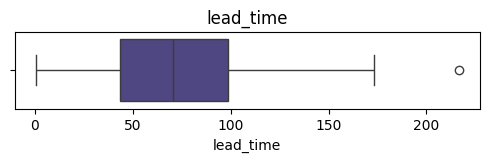

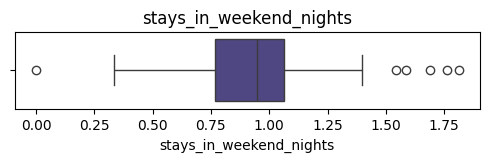

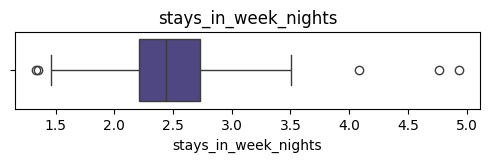

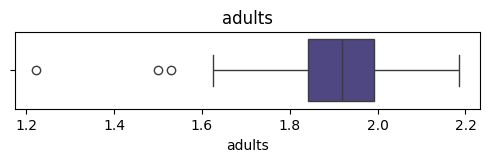

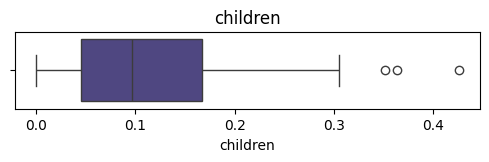

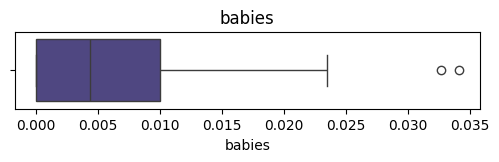

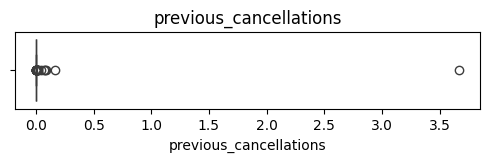

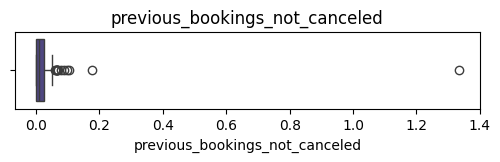

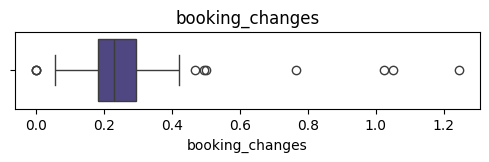

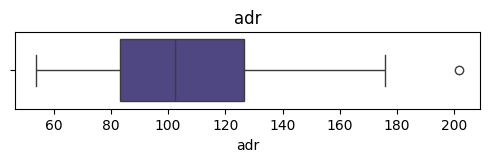

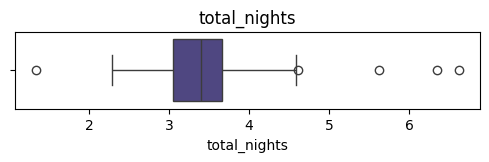

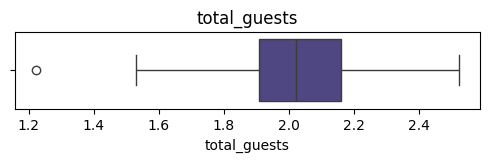

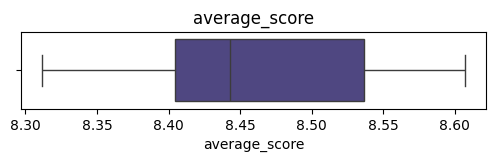

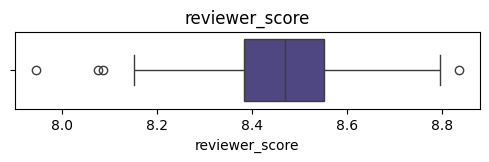

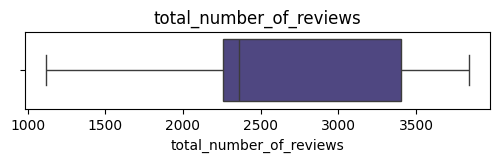

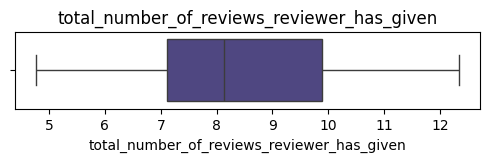

In [12]:
# Llamamos a la función de boxplots guardada en el archivo de soporte 
boxplots(booking_reviews)

El análisis univariado muestra que la mayoría de las variables numéricas presentan distribuciones sesgadas a la derecha y presencia de outliers.

- `lead_time`: bastante dispersa y con cola derecha marcada → hay reservas hechas con mucha antelación, pero no son la mayoría.
- `stays_in_weekend_nights` y `stays_in_week_nights`: concentradas en valores bajos → la mayoría de estancias son cortas.
- `adults`: muy poca variabilidad → casi siempre 2 adultos.
- `children` y `babies`: fuertemente concentradas en 0 → la mayoría de reservas no incluyen niños ni bebés.
- `previous_cancellations` y `previous_bookings_not_canceled`: muy concentradas en 0 con algunos outliers → la mayoría de clientes no tiene historial relevante, pero unos pocos sí son muy activos.
- `booking_changes`: valores bajos en general → pocas modificaciones por reserva, con algunos casos extremos.
- `adr`: dispersión moderada y algunos valores altos → existen reservas significativamente más caras que la media.
- `total_nights`: concentrada en estancias cortas (≈2–4 noches), con algunos outliers de estancias largas.
- `total_guests`: baja variabilidad → típicamente entre 1 y 2 personas.
- `average_score` y `reviewer_score`: muy concentradas en valores altos → distribuciones poco variables.
- `total_number_of_reviews`: alta dispersión → algunos hoteles tienen muchas más reseñas que otros.
- `total_number_of_reviews_reviewer_has_given`: ligera variabilidad, sin outliers extremos → comportamiento bastante homogéneo entre reviewers.

**Conclusión:**

En general, predominan reservas ‘típicas’: estancias cortas (2–4 noches), realizadas por 1–2 adultos, sin niños ni bebés y con escaso historial previo de reservas o cancelaciones. Variables como `lead_time`, `adr` y el número total de reseñas exhiben mayor dispersión y valores extremos, lo que indica la existencia de casos menos frecuentes pero relevantes (reservas con mucha antelación, precios elevados o alta actividad). Por otro lado, variables como las puntuaciones (`average_score` y `reviewer_score`) muestran baja variabilidad al concentrarse en valores altos.

---
### <span style="color:darkgray">**2. Análisis bivariado**</span>  

In [29]:
booking_reviews["reservation_status"].value_counts()

reservation_status
check_out    124
canceled       1
Name: count, dtype: int64

Tras la agregación de los datasets de reservas y reseñas, la variable `reservation_status` queda fuertemente desbalanceada, con una única categoría dominante (‘check_out’). Esto indica pérdida de variabilidad durante el proceso de unión, por lo que la variable no es adecuada para análisis bivariado ni como variable objetivo en este dataset transformado.

**Comportamiento del cliente** - Cómo reservan los clientes

✔ lead_time vs total_nights

✔ total_nights vs customer_type 

✔ lead_time vs market_segment

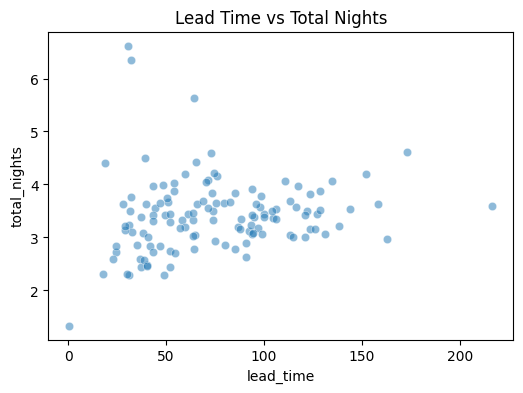

In [30]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=booking_reviews, x="lead_time", y="total_nights", alpha=0.5)
plt.title("Lead Time vs Total Nights")
plt.show()

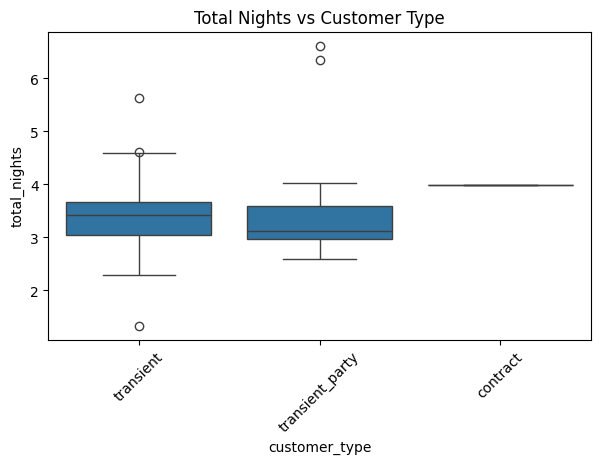

In [31]:
plt.figure(figsize=(7,4))
sns.boxplot(data=booking_reviews, x="customer_type", y="total_nights")
plt.title("Total Nights vs Customer Type")
plt.xticks(rotation=45)
plt.show()

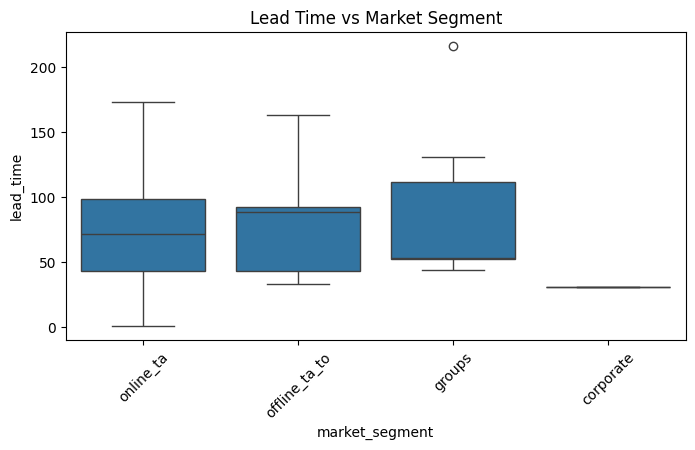

In [32]:
plt.figure(figsize=(8,4))
sns.boxplot(data=booking_reviews, x="market_segment", y="lead_time")
plt.title("Lead Time vs Market Segment")
plt.xticks(rotation=45)
plt.show()

💰 Precio (ADR) 

✔ adr vs market_segment
✔ adr vs customer_type
✔ adr vs total_nights
✔ adr vs lead_time

👉 Esto explica quién paga más y cuándo

⭐ Satisfacción (review / score)

✔ average_score vs hotel
✔ average_score vs adr
✔ average_score vs customer_type
✔ total_number_of_reviews vs score

👉 Esto conecta experiencia vs precio vs tipo de cliente

🔁 Fidelización / comportamiento histórico


👉 Esto mide clientes fieles vs problemáticos

🌍 Segmentación 

✔ market_segment vs customer_type
✔ country vs sentiment 

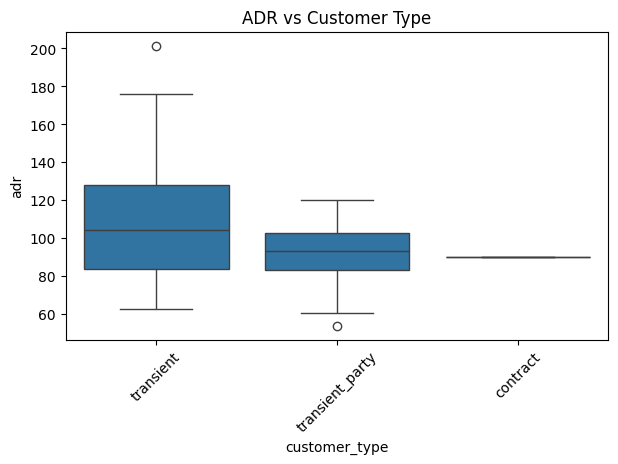

In [34]:
plt.figure(figsize=(7,4))
sns.boxplot(data=booking_reviews, x="customer_type", y="adr")
plt.title("ADR vs Customer Type")
plt.xticks(rotation=45)
plt.show()

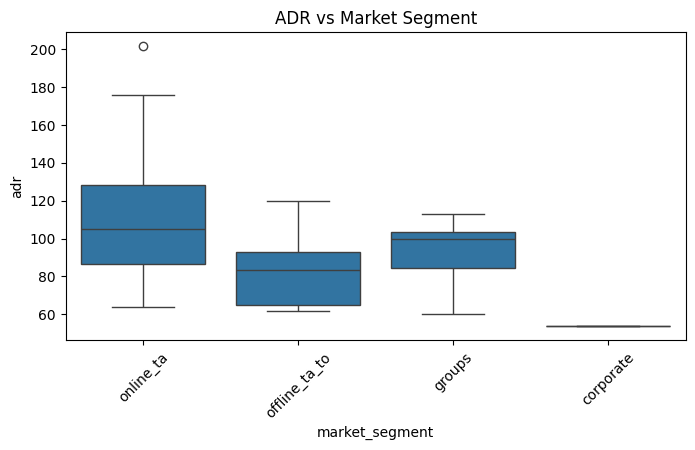

In [35]:
plt.figure(figsize=(8,4))
sns.boxplot(data=booking_reviews, x="market_segment", y="adr")
plt.title("ADR vs Market Segment")
plt.xticks(rotation=45)
plt.show()

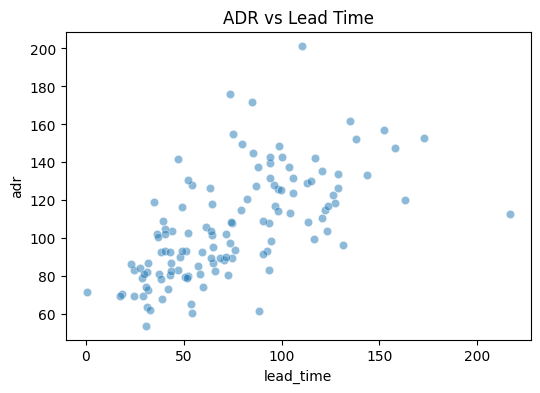

In [37]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=booking_reviews, x="lead_time", y="adr", alpha=0.5)
plt.title("ADR vs Lead Time")
plt.show()

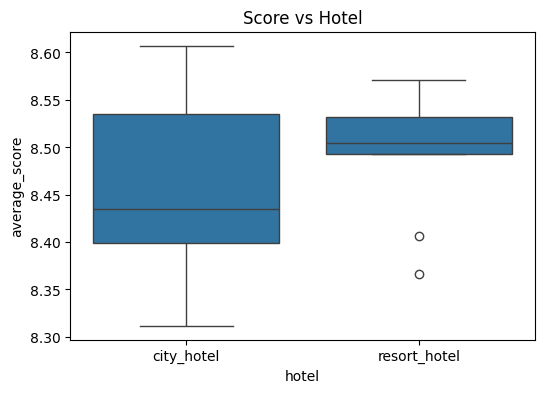

In [38]:
plt.figure(figsize=(6,4))
sns.boxplot(data=booking_reviews, x="hotel", y="average_score")
plt.title("Score vs Hotel")
plt.show()

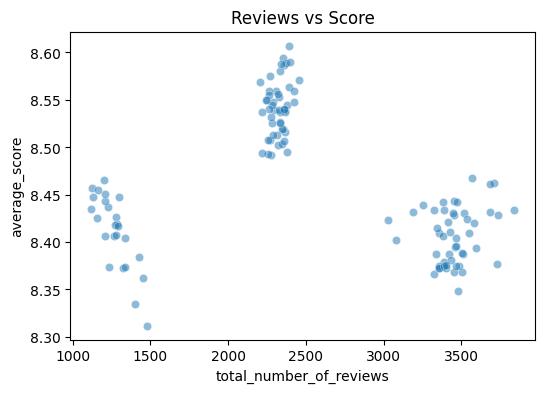

In [39]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=booking_reviews, x="total_number_of_reviews", y="average_score", alpha=0.5)
plt.title("Reviews vs Score")
plt.show()

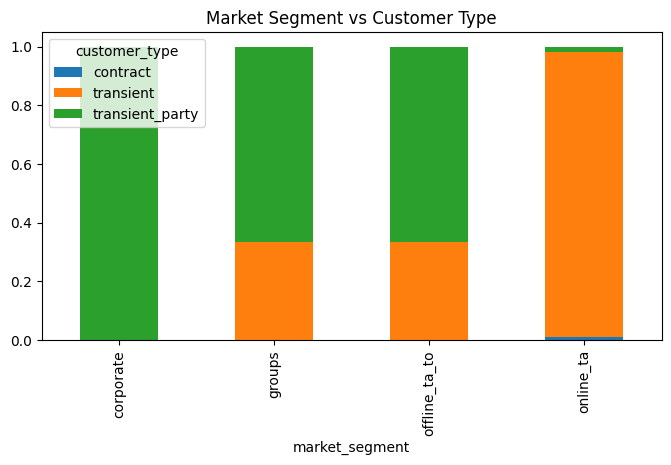

In [43]:
pd.crosstab(booking_reviews["market_segment"], booking_reviews["customer_type"], normalize="index").plot(kind="bar", stacked=True, figsize=(8,4))
plt.title("Market Segment vs Customer Type")
plt.show()

In [ ]:
booking_reviews["behavior_score"] = booking_reviews["previous_bookings_not_canceled"] - booking_reviews["previous_cancellations"]

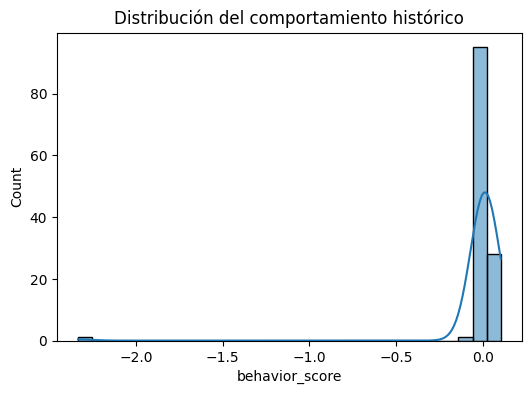

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(booking_reviews["behavior_score"], bins=30, kde=True)
plt.title("Distribución del comportamiento histórico")
plt.show()

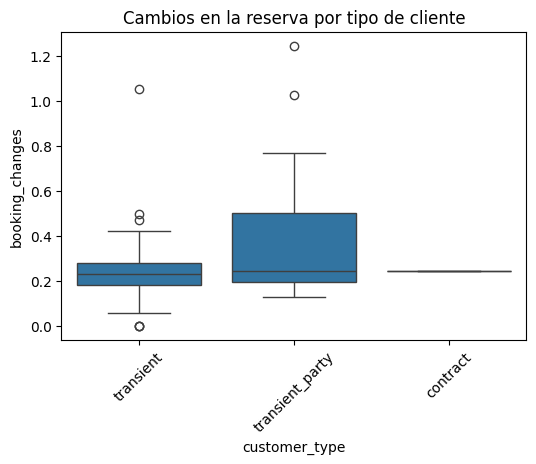

In [48]:
plt.figure(figsize=(6,4))
sns.boxplot(data=booking_reviews, x="customer_type", y="booking_changes")
plt.title("Cambios en la reserva por tipo de cliente")
plt.xticks(rotation=45)
plt.show()

***age vs subscribed***

- La mediana de edad para quienes se suscriben (yes) y no se suscriben (no) es bastante similar, alrededor de 35 años.
- La mayoría de los suscriptores están en el rango de 30–45 años.
- Hay varios valores atípicos en ambos grupos, especialmente por encima de los 60 años.

Conclusión: La edad por sí sola no parece un factor determinante fuerte para suscribirse.

***campaign_contacts vs subscribed***

- La mayoría de las personas han sido contactadas pocas veces (0–5) durante la campaña.
- Los no suscriptores muestran más valores atípicos en los contactos de campaña, con algunos recibiendo hasta 50 contactos.

Conclusión: Recibir más contactos no garantiza suscripción; de hecho, muchos que no se suscriben reciben más contactos, lo que sugiere saturación o contactos repetitivos sin éxito.

***employment_variation_rate vs subscribed***

- Los suscriptores tienden a tener una tasa de variación del empleo más baja (más cercana a cero o positiva), mientras que los no suscriptores tienen valores negativos más pronunciados.

Conclusión: Una economía o sector laboral más estable podría estar correlacionado con la suscripción.

***consumer_price_index vs subscribed***

- No hay una diferencia clara entre suscriptores y no suscriptores.
- La mediana y el rango son prácticamente iguales.

Conclusión: CPI no parece influir directamente en la decisión de suscribirse.

***consumer_confidence_index vs subscribed***

- Los valores medianos son similares entre ambos grupos.
- Hay algunos outliers positivos en los no suscriptores.

Conclusión: La confianza del consumidor no muestra un patrón claro con la suscripción.

***euribor_3m_rate vs subscribed***

- Los suscriptores tienden a registrarse cuando la tasa Euribor a 3 meses es más baja.
- Los no suscriptores muestran tasas más altas y más dispersión.

Conclusión: Las tasas de interés bajas podrían favorecer la suscripción.

***year vs subscribed***

- La distribución por años es muy similar entre suscriptores y no suscriptores.

Conclusión: El año de registro no influye significativamente en la suscripción.

***income vs subscribed***

- La mediana de ingresos es similar para ambos grupos.
- Ambos muestran una distribución amplia y outliers altos.

Conclusión: Los ingresos individuales no parecen ser un predictor fuerte de suscripción.

***num_web_visits_month vs subscribed***

- La mediana y rango son casi idénticos para ambos grupos.

Conclusión: La cantidad de visitas web al mes no diferencia claramente entre suscriptores y no suscriptores.



### <span style="color:darkgray">**4. Análisis multivariado**</span>  

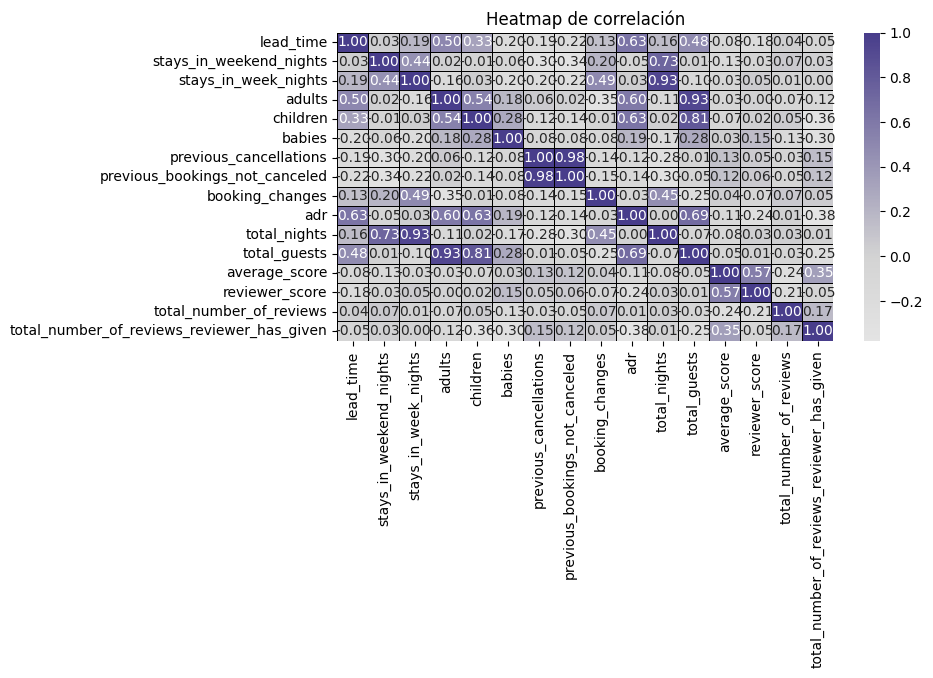

In [19]:
# Llamamos a la función que nos dibuja el heatmap guardada en el archivo de soporte
grafica_correlacion(booking_reviews)

🟣 **Correlaciones más fuertes (positivas):**

**`adults` ↔ `total_guests` (~0.93)**

- Más adultos implican directamente más huéspedes.

**`stays_in_week_nights` ↔ `total_nights` (~0.93)**

- Las noches entre semana dominan el total de noches.

**`stays_in_weekend_nights` ↔ `total_nights` (~0.73)**

- Las noches de fin de semana también influyen bastante en el total.

**`previous_cancellations` ↔ `previous_bookings_not_canceled` (~0.98)**

- Ambas variables reflejan el nivel de actividad del cliente: quienes reservan más tienden tanto a cancelar como a completar más reservas.

🟢 **Correlaciones moderadas:**

**`lead_time` ↔ `adr` (~0.63)**

- Reservas con más anticipación tienden a tener precios distintos.

`booking_changes` ↔ `adr` (~0.45)

- Cambios en la reserva se asocian moderadamente con el precio.

`total_guests` ↔ `adr` (~0.39)

- Más huéspedes pueden implicar mayor precio promedio.

⚪ **Correlaciones débiles o casi nulas:**

`babies`, `children`, `average_score`, `reviewer_score`

- Presentan valores cercanos a 0 → poca relación lineal con otras variables.

🔴 **Correlaciones negativas:**

`previous_cancellations` ↔ `` (~-0.12)

- Más cancelaciones se asocian ligeramente con precios más bajos.

`lead_time` ↔ `total_nights` (~-0.16)

- Reservas anticipadas tienden a ser ligeramente más cortas.


---
---
## <span style="color:gray">**Insights**</span> 💡

El análisis exploratorio muestra que las variables macroeconómicas, especialmente `employment_variation_rate` y `euribor_3m_rate`, presentan la mayor relación con la suscripción. Además, estas variables están fuertemente correlacionadas entre sí, lo que indica posible multicolinealidad.

Por otro lado, variables individuales como `age`, `income` y `num_web_visits_month` presentan correlaciones débiles, sugiriendo una baja influencia directa en la decisión del cliente.

En cuanto a variables categóricas, `previous_campaign_outcome` destaca como el factor más influyente, seguido por `contact_method` y `jo`b. Variables como `education_level` y `marital_status` muestran un impacto moderado, mientras que `default`, `housing_loan` y `personal_loan` tienen poca relevancia.

Finalmente, se observa que `campaign_contacts` no presenta una relación positiva clara con la suscripción, lo que indica que un mayor número de contactos no necesariamente mejora los resultados.

---
---
## <span style="color:gray">**Conclusiones finales**</span> 📝

Los resultados sugieren que la decisión de suscripción está más influenciada por factores externos, como las condiciones macroeconómicas, que por características personales del cliente.

El historial de campañas emerge como el factor más determinante, lo que indica que la información de interacciones previas es clave para predecir el comportamiento futuro.

Asimismo, el canal de contacto y ciertas variables sociodemográficas (como la ocupación) juegan un papel relevante, mientras que variables financieras como préstamos tienen un impacto limitado.

Dado que algunas variables macroeconómicas contienen información redundante, es recomendable realizar una selección cuidadosa de variables para evitar problemas de multicolinealidad en los modelos predictivos.

Por último, incrementar la cantidad de contactos no garantiza una mayor tasa de conversión, por lo que se recomienda optimizar la estrategia de contacto en lugar de simplemente aumentarla.